In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import default_collate
from model import LeNet, LeNet_dropout
from train_test import early_stop

In [2]:
# hyperparameters
learning_rate = 0.005
batch_size = 32
weight_decay = 1e-4

# pick accelerator
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
torch.set_default_device(device)

In [3]:
# load the data
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

collate_fn = lambda x: tuple(x_.to(device) for x_ in default_collate(x))
train_dataloader = DataLoader(train_data, batch_size=batch_size, collate_fn=collate_fn)
test_dataloader = DataLoader(test_data, batch_size=batch_size, collate_fn=collate_fn)


In [4]:
# instantiate models
model_regular = LeNet().to(device)
model_dropout = LeNet_dropout().to(device)

# loss function and optimizers
loss_fn = nn.CrossEntropyLoss()
optimizer_regular = torch.optim.AdamW(model_regular.parameters(), lr=learning_rate, weight_decay=weight_decay)
optimizer_dropout = torch.optim.AdamW(model_dropout.parameters(), lr=learning_rate, weight_decay=weight_decay)

epoch | train_loss | test_loss | accuracy(%)
1     |   0.5064   |   0.4044  |    85.21
2     |   0.3398   |   0.3449  |    87.69
3     |   0.3044   |   0.3344  |    87.61
4     |   0.2887   |   0.3281  |    87.89
5     |   0.2735   |   0.3549  |    87.47
6     |   0.2627   |   0.3166  |    88.45
7     |   0.2510   |   0.3570  |    87.84
8     |   0.2407   |   0.3473  |    88.40
9     |   0.2338   |   0.3360  |    88.76
10    |   0.2276   |   0.3272  |    88.64
11    |   0.2253   |   0.3449  |    88.82
12    |   0.2157   |   0.3414  |    89.15
13    |   0.2136   |   0.3604  |    89.20
14    |   0.2078   |   0.3639  |    89.43
15    |   0.2058   |   0.3819  |    88.98
16    |   0.2063   |   0.3761  |    89.01
Minimum test loss is 0.3166, achieved at epoch 6, with test accuracy 88.45%.
Maximum test accuracy is 89.43%, achieved at epoch 14.


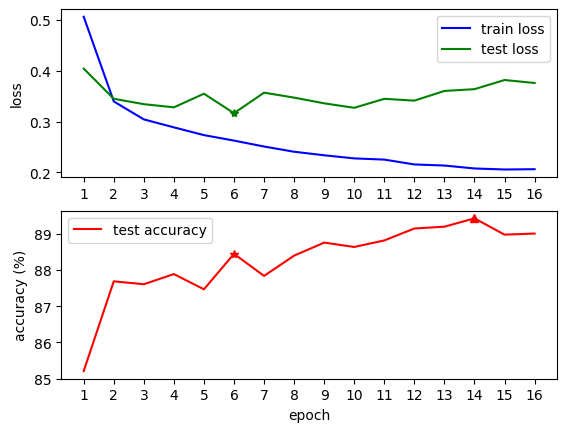

In [5]:
# train LeNet-5 (no dropout) using early stopping with patience=10
early_stop(train_dataloader, test_dataloader, model_regular, loss_fn, optimizer_regular, device, patience=10, show=True)

epoch | train_loss | test_loss | accuracy(%)
1     |   0.6336   |   0.4345  |    83.95
2     |   0.4761   |   0.4041  |    84.73
3     |   0.4454   |   0.3898  |    85.84
4     |   0.4198   |   0.3680  |    86.13
5     |   0.4191   |   0.4031  |    84.71
6     |   0.4059   |   0.3555  |    86.65
7     |   0.3991   |   0.3650  |    86.60
8     |   0.3966   |   0.3495  |    86.85
9     |   0.3941   |   0.3656  |    86.17
10    |   0.3879   |   0.3627  |    86.27
11    |   0.3856   |   0.3401  |    87.31
12    |   0.3895   |   0.3527  |    87.00
13    |   0.3794   |   0.3612  |    86.92
14    |   0.3872   |   0.3357  |    87.55
15    |   0.3852   |   0.3508  |    86.93
16    |   0.3759   |   0.3403  |    87.61
17    |   0.3819   |   0.3486  |    86.98
18    |   0.3782   |   0.3347  |    87.40
19    |   0.3778   |   0.3605  |    86.82
20    |   0.3778   |   0.3644  |    86.86
21    |   0.3790   |   0.3476  |    87.32
22    |   0.3764   |   0.3320  |    87.68
23    |   0.3727   |   0.3373  

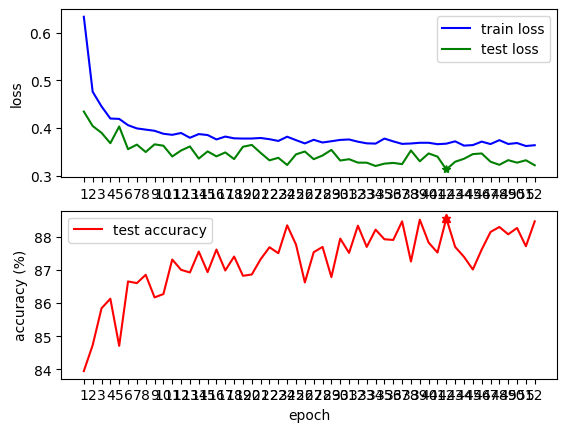

In [6]:
# train LeNet-5 (with dropout) using early stopping with patience=10
early_stop(train_dataloader, test_dataloader, model_dropout, loss_fn, optimizer_dropout, device, patience=10, show=True)